# Helical Diffraction and the Phase Problem — from Photo 51 to Gerchberg-Saxton

The single image that cracked DNA, **Photo 51**, is the X-ray diffraction pattern of a helix — a
bright **"X"**. Three threads of this whole project meet here:

1. **Bessel functions** — the Fourier transform of a helix lives on *layer lines* whose radial
   amplitude is $J_n$ (Cochran-Crick-Vand, 1952); the first maxima of successive $J_n$ trace the X.
2. **The phase problem** — a detector records intensity $|F|^2$ only. The phase of $F$ is lost, yet
   the phase is where most of the structural information lives. This *is* the repo's problem.
3. **Gerchberg-Saxton** — GS was invented for exactly this: recover the object from a Fourier
   *magnitude* plus a real-space constraint, by alternating projections. The TD-GS phase recovery in
   `gs_core.py` is the same algorithm with dispersion in place of the Fourier transform.

Engine: `xray_phase.py` (+ `griffiths.bessel` for the CCV layer lines).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import xray_phase as xp

print("xray_phase loaded")

xray_phase loaded


## §1 A helix and its diffraction: the X appears

Build the projected density of a double helix and Fourier-transform it. The diffraction is the famous
cross — and the *opening angle* of the X is set by the ratio of helix radius to pitch, while the
*spacing* of the layer lines along the meridian gives the pitch directly. (The double-strand offset
$\approx 3/8$ even reproduces B-DNA's missing 4th layer line.)

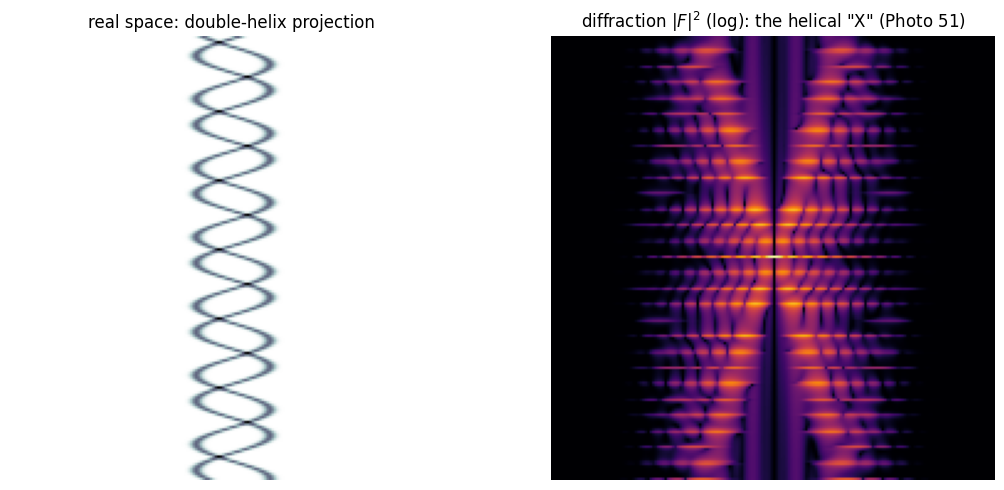

In [2]:
rho = xp.helix_density(N=180, pitch=28, radius=15, n_strands=2, offset=0.375)
D = xp.diffraction(rho)

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].imshow(rho, cmap="bone_r", origin="lower")
ax[0].set_title("real space: double-helix projection"); ax[0].axis("off")
ax[1].imshow(np.log1p(D), cmap="inferno", origin="lower")
ax[1].set_title('diffraction $|F|^2$ (log): the helical "X" (Photo 51)'); ax[1].axis("off")
plt.tight_layout(); plt.show()

## §2 Why it's an X: Bessel functions on layer lines

Cochran-Crick-Vand: the transform of a continuous helix is nonzero only on layer lines at height
$Z=n/P$, and on line $n$ the intensity is $I_n(R)\propto J_n(2\pi r R)^2$. The first maximum of
$J_n$ moves *outward* as $|n|$ grows, so successive layer lines peak farther from the meridian — and
joining those peaks draws the two arms of the X.

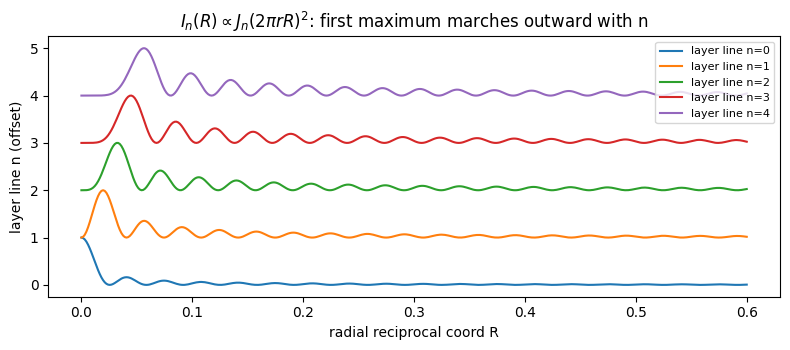

argument of first J_n maximum (grows with n -> the X opens): [1.84, 3.05, 4.2, 5.32, 6.42]


In [3]:
R = np.linspace(0, 0.6, 400)
r_helix = 15 / 180.0           # radius in pixel-fraction units
plt.figure(figsize=(8, 3.6))
for n in range(0, 5):
    In = xp.ccv_layer_intensity(n, r_helix * 180, R)
    plt.plot(R, In / In.max() + n, label=f"layer line n={n}")
plt.xlabel("radial reciprocal coord R"); plt.ylabel("layer line n (offset)")
plt.title("$I_n(R)\\propto J_n(2\\pi r R)^2$: first maximum marches outward with n")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

import mpmath as mp
firsts = [round(float(mp.besseljzero(n, 1, derivative=1)), 2) for n in range(1, 6)]
print("argument of first J_n maximum (grows with n -> the X opens):", firsts)

## §3 The phase problem: intensity throws the phase away

$F=|F|e^{i\phi}$, but the detector measures $|F|^2$. Two objects with the *same* $|F|$ but different
$\phi$ are indistinguishable to the detector — and it is the **phase** that carries the shape. Below:
keep one object's magnitude, swap in another's phase, and the image becomes the *other* object. Phase
dominates.

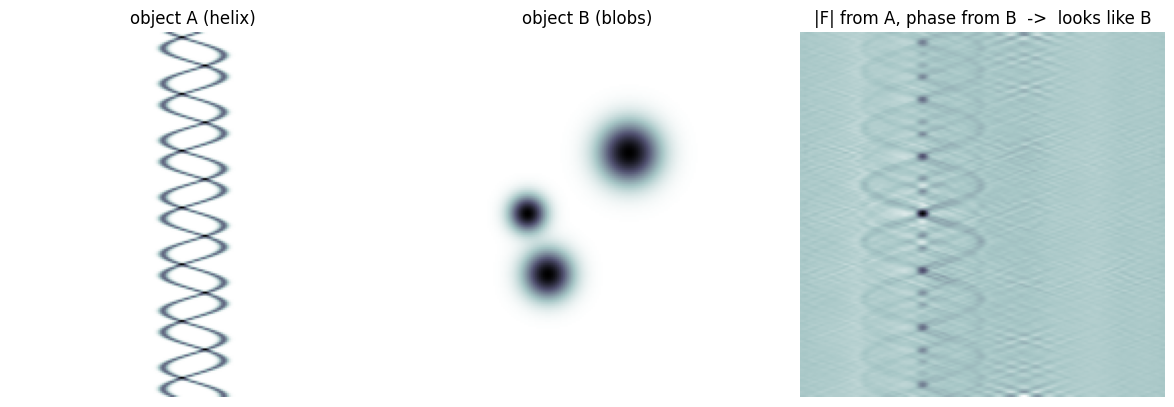

the magnitude is A's, but the picture is B's: phase carries the structure.


In [4]:
# classic demo: cross magnitude and phase of two different images
N = 180
a = xp.helix_density(N=N, pitch=28, radius=15, n_strands=2)
b = np.zeros((N, N)); yy, xx = np.mgrid[0:N, 0:N]
for (cy, cx, s) in [(60, 70, 8), (120, 110, 10), (90, 60, 6)]:   # blobs, totally different
    b += np.exp(-((yy-cy)**2 + (xx-cx)**2)/(2*s**2))
Fa, Fb = np.fft.fft2(a), np.fft.fft2(b)
mix = np.real(np.fft.ifft2(np.abs(Fa) * np.exp(1j*np.angle(Fb))))   # a's mag, b's phase

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(a, cmap="bone_r", origin="lower"); ax[0].set_title("object A (helix)"); ax[0].axis("off")
ax[1].imshow(b, cmap="bone_r", origin="lower"); ax[1].set_title("object B (blobs)"); ax[1].axis("off")
ax[2].imshow(mix, cmap="bone_r", origin="lower")
ax[2].set_title("|F| from A, phase from B  ->  looks like B"); ax[2].axis("off")
plt.tight_layout(); plt.show()
print("the magnitude is A's, but the picture is B's: phase carries the structure.")

## §4 Gerchberg-Saxton (Fienup HIO) recovers the object

Given only $|F|$ and a **support** (the object is known to be finite — and we *oversample* by
zero-padding, which makes the phase solution unique), iterate: enforce the measured $|F|$ in Fourier
space, enforce support + positivity in real space, repeat. This is the 2-D sibling of the repo's
TD-GS loop. The HIO error curve *bounces* (that's the algorithm escaping traps, not a failure); the
final error-reduction polish lands the answer.

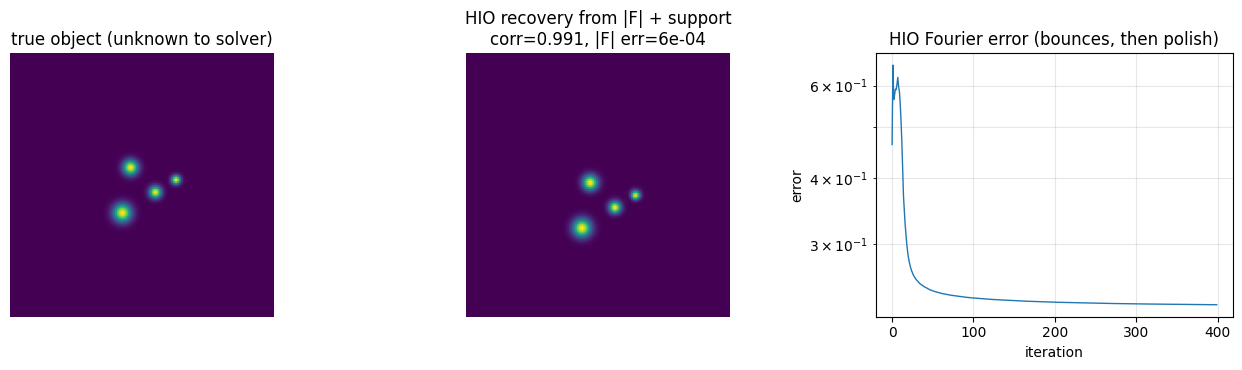

recovered from intensity alone: correlation 0.991, polished |F| error 5.99e-04


In [5]:
# asymmetric compact object on an oversampled grid (support = central quarter)
N = 128
truth = np.zeros((N, N)); yy, xx = np.mgrid[0:N, 0:N]
for (cy, cx, s) in [(50, 54, 3.0), (60, 70, 2.0), (72, 58, 2.5), (66, 80, 1.5)]:
    truth += np.exp(-((yy-cy)**2 + (xx-cx)**2)/(2*s**2))
support = np.zeros((N, N), dtype=bool); support[N//4:3*N//4, N//4:3*N//4] = True

mag = xp.amplitude(truth)
rec, errors = xp.hio_phase_retrieval(mag, support, n_iter=400, beta=0.9, seed=0)
corr = xp.best_alignment_corr(rec, truth)
final_err = np.linalg.norm(xp.amplitude(rec) - mag) / np.linalg.norm(mag)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
ax[0].imshow(truth, cmap="viridis", origin="lower"); ax[0].set_title("true object (unknown to solver)")
ax[0].axis("off")
ax[1].imshow(rec, cmap="viridis", origin="lower")
ax[1].set_title(f"HIO recovery from |F| + support\ncorr={corr:.3f}, |F| err={final_err:.0e}")
ax[1].axis("off")
ax[2].semilogy(errors, lw=1); ax[2].set_title("HIO Fourier error (bounces, then polish)")
ax[2].set_xlabel("iteration"); ax[2].set_ylabel("error"); ax[2].grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()
print(f"recovered from intensity alone: correlation {corr:.3f}, polished |F| error {final_err:.2e}")

## §5 The whole session, in one picture

This notebook closes the loop on everything built this summer:

- **Bessel (§2)** — the helix's diffraction is $J_n$ on layer lines, the same special function as the
  fibre LP modes and the hanging chain. One function, now drawing the structure of life.
- **Fourier + phase (§3-4)** — the phase problem and its Gerchberg-Saxton solution are *literally*
  `gs_core.py`'s TD-GS, swapped from the dispersion transform to the 2-D Fourier transform. Measured
  magnitude + a constraint (support here, a second dispersion there) → recovered phase.
- **The repo's thesis, generalized** — carrier-less optical phase recovery and X-ray crystallography
  are the same inverse problem: *reconstruct a complex field from intensity measurements*. The diversity
  that makes it solvable is oversampling/support in crystallography and dispersion ($|D|\sim5000$) in
  the time-stretch system.

Photo 51 recovered a structure from intensity-only data by hand and insight in 1953; the same problem,
the same algorithm family, runs your dispersion-assisted phase recovery today.

Engine added this session: `xray_phase.py` (helix density, diffraction, CCV layer lines, Fienup HIO),
benchmarked in `scripts/smoke_xray.py`.